# 02B: Cluster-Aware Stock Price Regression

## Objective
Use 03A K-Means clustering results to improve next-day stock price regression.

## What This Notebook Adds
1. Add cluster labels as regression features (one-hot encoded)
2. Build cluster-specific engineered features
3. Add market-state awareness derived from cluster profile
4. Train cluster-specific regressors
5. Fuse global and cluster-specific predictions

In [106]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost kagglehub

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import kagglehub

sns.set_palette('husl')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

Note: you may need to restart the kernel to use updated packages.


In [107]:
# Resolve project paths
cwd = Path.cwd()
REG_TASK = '02_stock_price_regression'
CLUSTER_TASK = '03_stock_clustering_analysis'

if cwd.name == 'implementation':
    reg_root = cwd.parent
elif cwd.name == REG_TASK:
    reg_root = cwd
elif (cwd / REG_TASK).exists():
    reg_root = cwd / REG_TASK
else:
    reg_root = cwd

workspace_root = reg_root.parent
cluster_root = workspace_root / CLUSTER_TASK

REG_GRAPH_DIR = reg_root / 'graph'
REG_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

cluster_data_dir = cluster_root / 'data'
raw_cache = cluster_data_dir / 'sp500_raw.csv'
cluster_assign_path = cluster_data_dir / '03A_stock_cluster_assignments.csv'
cluster_summary_path = cluster_data_dir / '03A_cluster_feature_summary.csv'

print(f'Regression root: {reg_root}')
print(f'Cluster root: {cluster_root}')
print(f'Using cluster assignments: {cluster_assign_path.name}')

Regression root: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\02_stock_price_regression
Cluster root: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis
Using cluster assignments: 03A_stock_cluster_assignments.csv


In [108]:
# Load price data (prefer shared cache from clustering project)
if raw_cache.exists():
    data = pd.read_csv(raw_cache)
    print('[CACHE] Loaded shared raw cache from clustering module')
else:
    print('[DOWNLOAD] Fetching Kaggle dataset...')
    path = kagglehub.dataset_download('camnugent/sandp500')
    csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
    data = pd.read_csv(os.path.join(path, csv_file))

if not cluster_assign_path.exists() or not cluster_summary_path.exists():
    raise FileNotFoundError('Please run 03A_KMeans_Clustering.ipynb first to generate cluster outputs.')

cluster_assign = pd.read_csv(cluster_assign_path)
cluster_summary = pd.read_csv(cluster_summary_path)

print(f'Price rows: {len(data)}')
print(f'Cluster assignments rows: {len(cluster_assign)}')
print(f"Cluster count from 03A: {cluster_assign['cluster'].nunique()}")

[CACHE] Loaded shared raw cache from clustering module
Price rows: 619040
Cluster assignments rows: 505
Cluster count from 03A: 6


## Step 1: Build Regression Dataset and Merge Cluster Labels

In [109]:
# Use all stocks from the largest 3 clusters (by unique stock count)
cluster_stock_map = cluster_assign[['Name', 'cluster']].drop_duplicates()
cluster_size = (
    cluster_stock_map.groupby('cluster')['Name']
    .nunique()
    .sort_values(ascending=False)
)
top_clusters = cluster_size.head(3).index.astype(int).tolist()
top_clusters_sorted = sorted(top_clusters)

available_symbols = set(data['Name'].unique())
selected = sorted(
    s for s in cluster_stock_map[cluster_stock_map['cluster'].isin(top_clusters)]['Name'].unique()
    if s in available_symbols
)

if len(selected) == 0:
    raise ValueError('No overlapping stocks found between data and top 3 clusters.')

cluster_counts_selected = (
    cluster_stock_map[cluster_stock_map['Name'].isin(selected)]
    .groupby('cluster')['Name']
    .nunique()
    .sort_index()
)

data_filtered = data[data['Name'].isin(selected)].copy()
data_filtered = data_filtered.sort_values(['Name', 'date']).reset_index(drop=True)

def create_regression_features(stock_df):
    stock_df = stock_df.sort_values('date').reset_index(drop=True).copy()

    stock_df['target'] = stock_df['close'].shift(-1)

    stock_df['price_range'] = (stock_df['high'] - stock_df['low']) / stock_df['open']
    stock_df['close_open_diff'] = (stock_df['close'] - stock_df['open']) / stock_df['open']
    stock_df['high_low_ratio'] = stock_df['high'] / stock_df['low']

    stock_df['daily_return'] = stock_df['close'].pct_change()
    stock_df['lag_return_1'] = stock_df['daily_return'].shift(1)
    stock_df['lag_return_5'] = stock_df['close'].pct_change(5)

    stock_df['volume_norm'] = stock_df['volume'] / stock_df['volume'].rolling(20).mean()
    stock_df['volume_trend'] = (stock_df['volume'] - stock_df['volume'].rolling(20).mean()) / stock_df['volume'].rolling(20).mean()

    stock_df['close_ma5'] = stock_df['close'].rolling(5).mean()
    stock_df['close_ma20'] = stock_df['close'].rolling(20).mean()
    stock_df['close_ma50'] = stock_df['close'].rolling(50).mean()

    stock_df['momentum_5'] = (stock_df['close'] - stock_df['close'].shift(5)) / stock_df['close'].shift(5)
    stock_df['momentum_20'] = (stock_df['close'] - stock_df['close'].shift(20)) / stock_df['close'].shift(20)

    stock_df['volatility_20'] = stock_df['daily_return'].rolling(20).std()
    stock_df['volatility_60'] = stock_df['daily_return'].rolling(60).std()

    delta = stock_df['daily_return'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    stock_df['rsi'] = 100 - (100 / (1 + rs))

    # Keep clustering-compatible features for centroid distance engineering
    stock_df['clu_volatility'] = stock_df['close'].pct_change().rolling(20).std()
    stock_df['clu_avg_return'] = stock_df['close'].pct_change().rolling(20).mean()
    stock_df['clu_avg_volume'] = stock_df['volume'].rolling(20).mean()
    stock_df['clu_volume_volatility'] = stock_df['volume'].rolling(20).std() / stock_df['volume'].rolling(20).mean()
    stock_df['clu_momentum'] = (stock_df['close'] - stock_df['close'].shift(20)) / stock_df['close'].shift(20)
    stock_df['clu_price_range'] = (stock_df['high'] - stock_df['low']) / stock_df['close']
    stock_df['clu_trend_strength'] = (stock_df['close'] - stock_df['low']) / (stock_df['high'] - stock_df['low'])
    stock_df['clu_price_level'] = stock_df['close'] / 100
    stock_df['clu_volume_to_price_ratio'] = stock_df['volume'] / stock_df['close']

    return stock_df

reg_df = pd.concat([create_regression_features(data_filtered[data_filtered['Name'] == s]) for s in selected], ignore_index=True)
reg_df = reg_df.dropna().reset_index(drop=True)

# Merge static cluster labels per stock
cluster_map = cluster_assign[['Name', 'cluster']].drop_duplicates('Name')
reg_df = reg_df.merge(cluster_map, on='Name', how='left')

missing_cluster = reg_df['cluster'].isna().mean()
if missing_cluster > 0:
    raise ValueError(f'Missing cluster labels for {missing_cluster:.1%} rows. Ensure 03A universe overlaps with regression stocks.')

reg_df['cluster'] = reg_df['cluster'].astype(int)

selected_cluster_text = ', '.join(map(str, top_clusters_sorted))
print(f'Selected clusters: {selected_cluster_text}')
print('Stocks per selected cluster:')
print(cluster_counts_selected.to_string())
print(f'Total selected stocks: {len(selected)}')
print(f'Regression rows after merge: {len(reg_df)}')
preview = reg_df[['Name', 'cluster']].drop_duplicates().sort_values(['cluster', 'Name'])
print(preview.head(20))

Selected clusters: 0, 1, 4
Stocks per selected cluster:
cluster
0    286
1    139
4     71
Total selected stocks: 496
Regression rows after merge: 577747
       Name  cluster
0         A        0
2396    AAP        0
3594   AAPL        0
7188    ABT        0
8386    ACN        0
9584   ADBE        0
10782   ADI        0
11980   ADM        0
13178   ADP        0
15574  ADSK        0
16772   AEE        0
17970   AEP        0
19168   AES        0
20366   AET        0
25158   AIV        0
26356   AIZ        0
33544   ALL        0
34742  ALLE        0
38140   AME        0
39338   AMG        0


## Step 1.1: K-Means Cluster Group Insights (ML + Finance)

Review selected clusters with machine-learning style centroid profiles and finance-oriented risk/return views.

Selected K-Means clusters profile:


,cluster,n_stocks,volatility,avg_return,avg_volume,volume_volatility,momentum,price_range,trend_strength,price_level,volume_to_price_ratio,risk_return_ratio
0,0,286,0.0154,-0.0021,3.768906e+06,0.3594,-0.0433,0.0253,0.1739,1.0233,73977.8572,-0.136364
1,1,139,0.0208,0.0021,4.968325e+06,0.4488,0.0383,0.0345,0.4760,1.0404,125753.0889,0.100962
2,4,71,0.0240,-0.0058,5.580841e+06,0.5299,-0.1143,0.0413,0.2162,0.7349,204601.2295,-0.241667


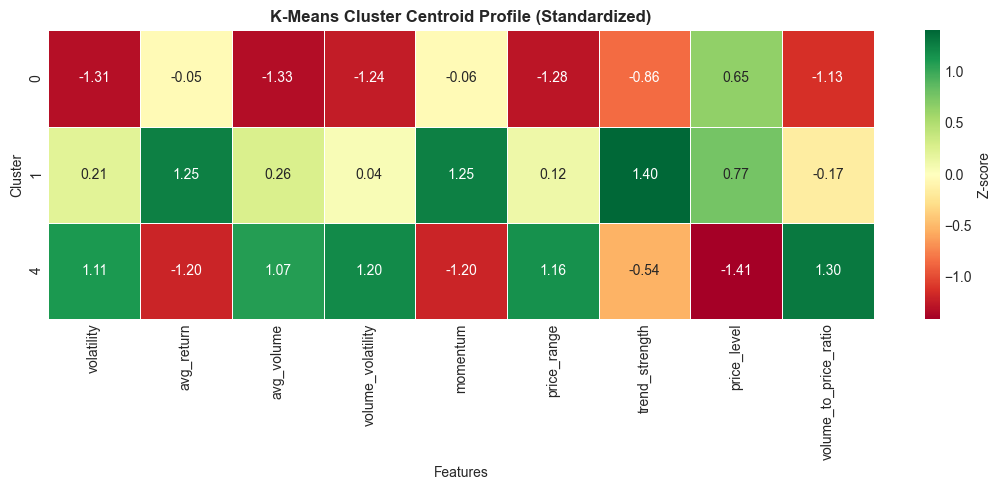

[OK] Saved: 08K_cluster_centroid_profile_heatmap.png


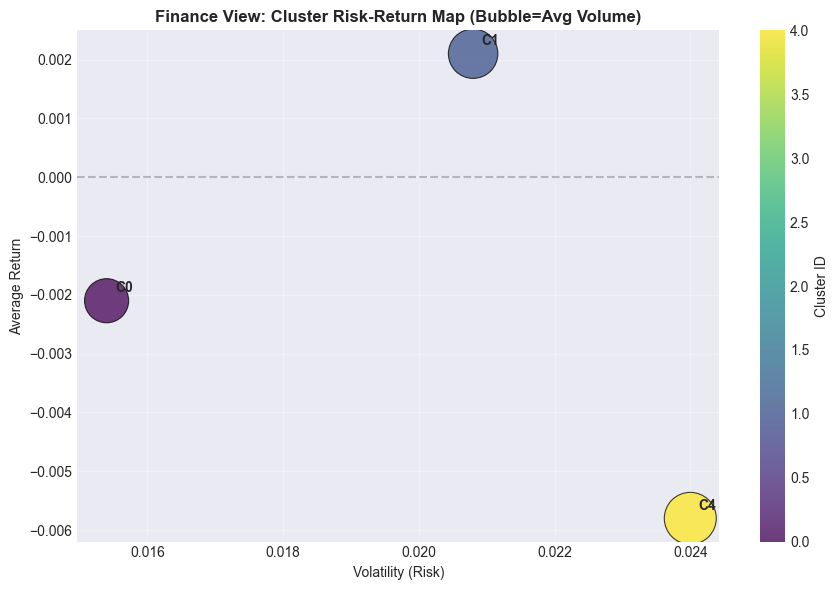

[OK] Saved: 08L_cluster_finance_risk_return_map.png


In [110]:
# K-Means related info for selected clusters
base_cols = [
    'cluster', 'volatility', 'avg_return', 'avg_volume', 'volume_volatility',
    'momentum', 'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio'
]

missing_base = [c for c in base_cols if c not in cluster_summary.columns]
if missing_base:
    raise KeyError(f'Missing required columns in cluster_summary: {missing_base}')

cluster_profile = cluster_summary[cluster_summary['cluster'].isin(top_clusters_sorted)][base_cols].copy()

# Build stock count robustly from assignment file (works even if summary schema changes)
stock_counts = (
    cluster_assign[['Name', 'cluster']]
    .drop_duplicates()
    .groupby('cluster')['Name']
    .nunique()
    .rename('n_stocks')
    .reset_index()
)
cluster_profile = cluster_profile.merge(stock_counts, on='cluster', how='left')
cluster_profile['n_stocks'] = cluster_profile['n_stocks'].fillna(0).astype(int)

cluster_profile = cluster_profile.sort_values('cluster').reset_index(drop=True)
cluster_profile['risk_return_ratio'] = cluster_profile['avg_return'] / cluster_profile['volatility'].replace(0, np.nan)

# Place n_stocks near cluster id for readability
ordered_cols = [
    'cluster', 'n_stocks', 'volatility', 'avg_return', 'avg_volume', 'volume_volatility',
    'momentum', 'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio', 'risk_return_ratio'
]
cluster_profile = cluster_profile[ordered_cols]

print('Selected K-Means clusters profile:')
display(cluster_profile)

# ML graph: standardized centroid feature heatmap
ml_feature_cols = [
    'volatility', 'avg_return', 'avg_volume', 'volume_volatility',
    'momentum', 'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio'
]
z_profile = cluster_profile.set_index('cluster')[ml_feature_cols].copy()
z_profile = (z_profile - z_profile.mean()) / (z_profile.std(ddof=0).replace(0, 1))

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    z_profile,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Z-score'},
    ax=ax
)
ax.set_title('K-Means Cluster Centroid Profile (Standardized)', fontsize=12, fontweight='bold')
ax.set_xlabel('Features')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig(str(REG_GRAPH_DIR / '08K_cluster_centroid_profile_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print('[OK] Saved: 08K_cluster_centroid_profile_heatmap.png')

# Finance graph: risk-return map with volume as bubble size
finance_df = cluster_profile[['cluster', 'avg_return', 'volatility', 'avg_volume', 'risk_return_ratio']].copy()
finance_df['bubble_size'] = (finance_df['avg_volume'] / finance_df['avg_volume'].max()) * 1200 + 200

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    finance_df['volatility'],
    finance_df['avg_return'],
    s=finance_df['bubble_size'],
    c=finance_df['cluster'],
    cmap='viridis',
    alpha=0.75,
    edgecolors='black',
    linewidths=0.8
)

for _, row in finance_df.iterrows():
    ax.annotate(
        f"C{int(row['cluster'])}",
        (row['volatility'], row['avg_return']),
        textcoords='offset points',
        xytext=(6, 6),
        fontsize=10,
        fontweight='bold'
    )

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Finance View: Cluster Risk-Return Map (Bubble=Avg Volume)', fontsize=12, fontweight='bold')
ax.set_xlabel('Volatility (Risk)')
ax.set_ylabel('Average Return')
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster ID')

plt.tight_layout()
plt.savefig(str(REG_GRAPH_DIR / '08L_cluster_finance_risk_return_map.png'), dpi=300, bbox_inches='tight')
plt.show()
print('[OK] Saved: 08L_cluster_finance_risk_return_map.png')

## Step 2: Cluster-Aware Feature Engineering

In [111]:
# Prepare cluster centroids from 03A summary for distance-to-centroid feature
centroid_cols = [
    'volatility', 'avg_return', 'avg_volume', 'volume_volatility', 'momentum',
    'price_range', 'trend_strength', 'price_level', 'volume_to_price_ratio'
]

centroids = cluster_summary.set_index('cluster')[centroid_cols].copy()

rename_map = {
    'clu_volatility': 'volatility',
    'clu_avg_return': 'avg_return',
    'clu_avg_volume': 'avg_volume',
    'clu_volume_volatility': 'volume_volatility',
    'clu_momentum': 'momentum',
    'clu_price_range': 'price_range',
    'clu_trend_strength': 'trend_strength',
    'clu_price_level': 'price_level',
    'clu_volume_to_price_ratio': 'volume_to_price_ratio'
}

clu_feature_cols = list(rename_map.keys())

def row_centroid_distance(row):
    c = int(row['cluster'])
    vec = np.array([row[col] for col in clu_feature_cols], dtype=float)
    cen = centroids.loc[c].values.astype(float)
    return float(np.linalg.norm(vec - cen))

reg_df['cluster_centroid_distance'] = reg_df.apply(row_centroid_distance, axis=1)

# Identify high-volatility vs defensive clusters from 03A summary
cluster_vol_rank = centroids['volatility'].sort_values(ascending=False)
high_vol_cluster = int(cluster_vol_rank.index[0])
defensive_cluster = int(cluster_vol_rank.index[-1])

reg_df['is_high_vol_cluster'] = (reg_df['cluster'] == high_vol_cluster).astype(int)
reg_df['is_defensive_cluster'] = (reg_df['cluster'] == defensive_cluster).astype(int)

# Group-specific interaction features
reg_df['momentum_x_volume_highvol'] = reg_df['momentum_20'] * reg_df['volume_norm'] * reg_df['is_high_vol_cluster']
reg_df['ma_gap_defensive'] = (reg_df['close_ma20'] - reg_df['close_ma50']) * reg_df['is_defensive_cluster']
reg_df['volatility_cluster_interact'] = reg_df['volatility_20'] * (reg_df['cluster'] + 1)

# Market state proxy based on cluster expected return sign
cluster_return = centroids['avg_return']
bull_clusters = set(cluster_return[cluster_return > 0].index.astype(int))
bear_clusters = set(cluster_return[cluster_return < 0].index.astype(int))
reg_df['market_state'] = np.where(reg_df['cluster'].isin(list(bull_clusters)), 'bull_like',
                           np.where(reg_df['cluster'].isin(list(bear_clusters)), 'bear_like', 'neutral_like'))

print(f'High-vol cluster: {high_vol_cluster}')
print(f'Defensive cluster: {defensive_cluster}')
print(reg_df[['cluster', 'market_state']].drop_duplicates().sort_values('cluster'))

High-vol cluster: 3
Defensive cluster: 0
       cluster market_state
0            0    bear_like
1198         1    bull_like
14376        4    bear_like


Cluster detail summary:


,cluster,n_rows,n_stocks,avg_target,median_target,avg_volatility_20,avg_momentum_20,avg_centroid_distance,market_state
0,0,333505,286,82.821207,67.98,0.012979,0.010482,2.811051e+06,bear_like
1,1,161777,138,75.125876,60.72,0.014969,0.013082,3.964056e+06,bull_like
2,4,82465,71,71.166918,52.69,0.016931,0.009318,3.973874e+06,bear_like


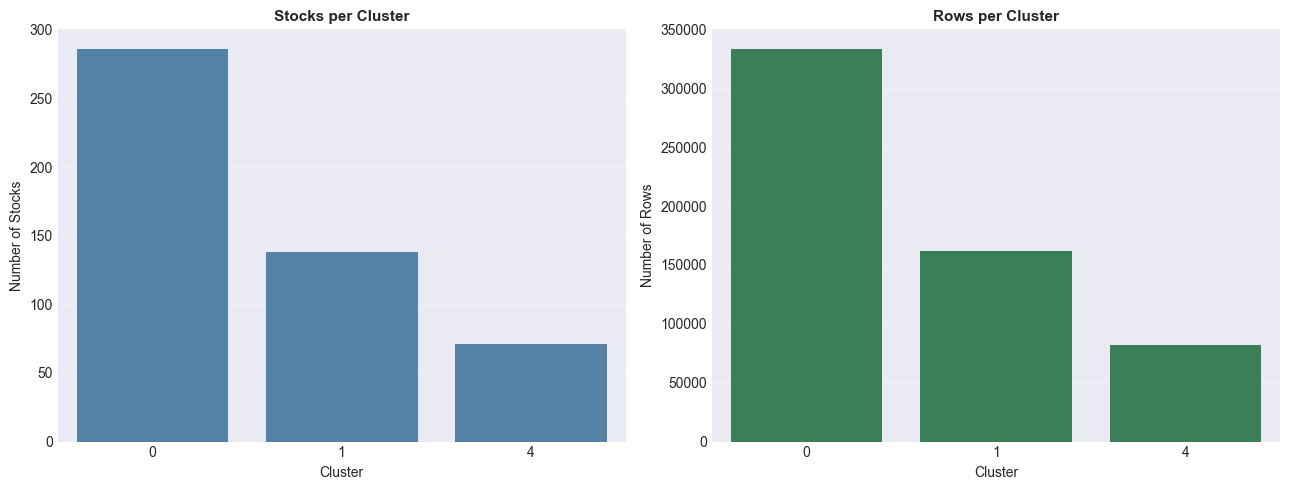

[OK] Saved: 08A_cluster_distribution_top3.png


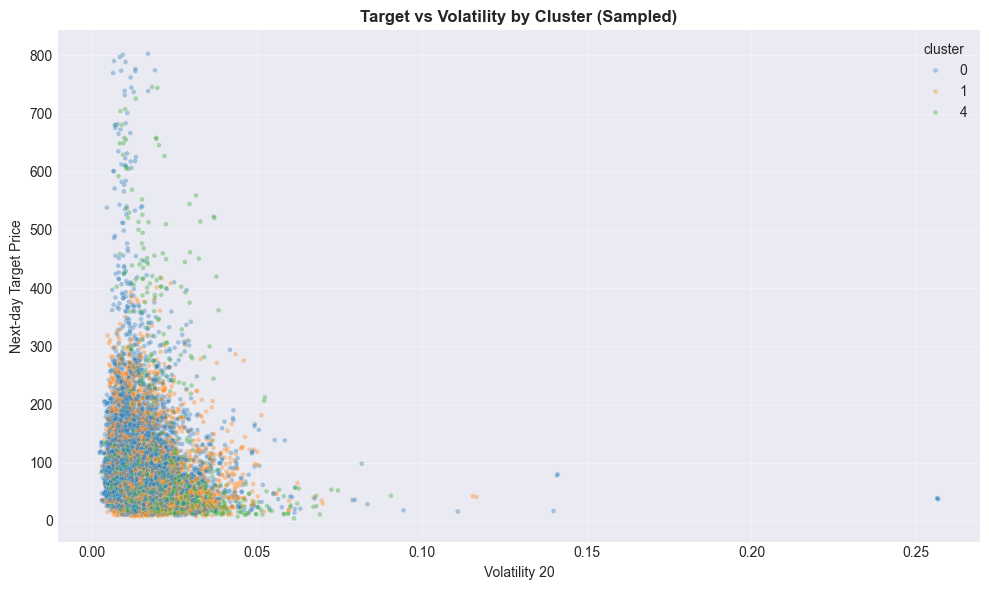

[OK] Saved: 08B_cluster_target_volatility_relation.png


In [112]:
# Cluster detail summary + relationship visuals
cluster_detail_df = (
    reg_df.groupby('cluster')
    .agg(
        n_rows=('Name', 'size'),
        n_stocks=('Name', 'nunique'),
        avg_target=('target', 'mean'),
        median_target=('target', 'median'),
        avg_volatility_20=('volatility_20', 'mean'),
        avg_momentum_20=('momentum_20', 'mean'),
        avg_centroid_distance=('cluster_centroid_distance', 'mean')
    )
    .reset_index()
    .sort_values('n_stocks', ascending=False)
)

cluster_state_df = (
    reg_df[['cluster', 'market_state']]
    .drop_duplicates()
    .sort_values('cluster')
)
cluster_detail_df = cluster_detail_df.merge(cluster_state_df, on='cluster', how='left')

print('Cluster detail summary:')
display(cluster_detail_df)

# Graph 1: stock count and row count by cluster
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=cluster_detail_df, x='cluster', y='n_stocks', ax=axes[0], color='steelblue')
axes[0].set_title('Stocks per Cluster', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Number of Stocks')
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(data=cluster_detail_df, x='cluster', y='n_rows', ax=axes[1], color='seagreen')
axes[1].set_title('Rows per Cluster', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Number of Rows')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(REG_GRAPH_DIR / '08A_cluster_distribution_top3.png'), dpi=300, bbox_inches='tight')
plt.show()
print('[OK] Saved: 08A_cluster_distribution_top3.png')

# Graph 2: relationship view (volatility vs target, colored by cluster)
sample_n = min(25000, len(reg_df))
plot_df = reg_df[['cluster', 'volatility_20', 'target']].sample(n=sample_n, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x='volatility_20',
    y='target',
    hue='cluster',
    palette='tab10',
    alpha=0.35,
    s=12,
    ax=ax
)
ax.set_title('Target vs Volatility by Cluster (Sampled)', fontsize=12, fontweight='bold')
ax.set_xlabel('Volatility 20')
ax.set_ylabel('Next-day Target Price')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(REG_GRAPH_DIR / '08B_cluster_target_volatility_relation.png'), dpi=300, bbox_inches='tight')
plt.show()
print('[OK] Saved: 08B_cluster_target_volatility_relation.png')

In [113]:
# One-hot encode cluster and market_state
reg_df = pd.get_dummies(reg_df, columns=['cluster', 'market_state'], drop_first=False)

base_features = [
    'price_range', 'close_open_diff', 'high_low_ratio', 'daily_return', 'lag_return_1', 'lag_return_5',
    'volume_norm', 'volume_trend', 'close_ma5', 'close_ma20', 'close_ma50',
    'momentum_5', 'momentum_20', 'volatility_20', 'volatility_60', 'rsi'
]

cluster_features = [c for c in reg_df.columns if c.startswith('cluster_')] + [
    'cluster_centroid_distance', 'is_high_vol_cluster', 'is_defensive_cluster',
    'momentum_x_volume_highvol', 'ma_gap_defensive', 'volatility_cluster_interact'
] + [c for c in reg_df.columns if c.startswith('market_state_')]

all_features = base_features + cluster_features
target_col = 'target'

print(f'Base features: {len(base_features)}')
print(f'Cluster-aware extra features: {len(cluster_features)}')
print(f'Total enhanced features: {len(all_features)}')

Base features: 16
Cluster-aware extra features: 12
Total enhanced features: 28


## Step 3: Train/Test Split (Chronological)

In [114]:
# Chronological split to reduce leakage
reg_df['date'] = pd.to_datetime(reg_df['date'])
split_date = reg_df['date'].quantile(0.8)

train_df = reg_df[reg_df['date'] <= split_date].copy()
test_df = reg_df[reg_df['date'] > split_date].copy()

X_train_base = train_df[base_features].copy()
X_test_base = test_df[base_features].copy()

X_train_enh = train_df[all_features].copy()
X_test_enh = test_df[all_features].copy()

y_train = train_df[target_col].values
y_test = test_df[target_col].values

scaler_base = StandardScaler()
X_train_base_scaled = scaler_base.fit_transform(X_train_base)
X_test_base_scaled = scaler_base.transform(X_test_base)

scaler_enh = StandardScaler()
X_train_enh_scaled = scaler_enh.fit_transform(X_train_enh)
X_test_enh_scaled = scaler_enh.transform(X_test_enh)

print(f'Split date: {split_date.date()}')
print(f'Train rows: {len(train_df)} | Test rows: {len(test_df)}')

Split date: 2017-03-03
Train rows: 462497 | Test rows: 115250


## Step 4: Modeling - Global vs Cluster-Aware vs Cluster-Specific vs Blended

In [115]:
def evaluate(y_true, y_pred):
    return {
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAPE': float(mean_absolute_percentage_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred))
    }

results = {}
MIN_CLUSTER_SAMPLES = 200

# Global baseline (no cluster features)
global_base = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=42,
    objective='reg:squarederror', n_jobs=-1
)
global_base.fit(X_train_base_scaled, y_train)
pred_base = global_base.predict(X_test_base_scaled)
results['Global Baseline'] = evaluate(y_test, pred_base)

# Global enhanced (with cluster-aware features)
global_enh = XGBRegressor(
    n_estimators=350, max_depth=6, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=42,
    objective='reg:squarederror', n_jobs=-1
)
global_enh.fit(X_train_enh_scaled, y_train)
pred_enh = global_enh.predict(X_test_enh_scaled)
results['Global + Cluster Features'] = evaluate(y_test, pred_enh)

# Build cluster list once from one-hot columns
cluster_cols = [c for c in reg_df.columns if c.startswith('cluster_') and c[len('cluster_'):].isdigit()]
cluster_ids = sorted([int(c.split('_')[1]) for c in cluster_cols])

# -------------------------------------------------
# Tune blend weight on a strict in-train time split
# -------------------------------------------------
val_cutoff = train_df['date'].quantile(0.85)
train_core_df = train_df[train_df['date'] <= val_cutoff].copy()
val_df = train_df[train_df['date'] > val_cutoff].copy()

if len(val_df) < 50:
    split_idx = int(len(train_df) * 0.85)
    train_core_df = train_df.iloc[:split_idx].copy()
    val_df = train_df.iloc[split_idx:].copy()

X_train_core = train_core_df[all_features].values
X_val = val_df[all_features].values
y_train_core = train_core_df[target_col].values
y_val = val_df[target_col].values

scaler_core = StandardScaler()
X_train_core_scaled = scaler_core.fit_transform(X_train_core)
X_val_scaled = scaler_core.transform(X_val)

global_core = XGBRegressor(
    n_estimators=320, max_depth=6, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=42,
    objective='reg:squarederror', n_jobs=-1
)
global_core.fit(X_train_core_scaled, y_train_core)
pred_enh_val = global_core.predict(X_val_scaled)

pred_cluster_val = np.full(len(val_df), np.nan, dtype=float)
cluster_models_val = {}

for cid in cluster_ids:
    ccol = f'cluster_{cid}'
    tr_idx = train_core_df.index[train_core_df[ccol] == 1].tolist()
    val_idx = val_df.index[val_df[ccol] == 1].tolist()

    if len(tr_idx) < MIN_CLUSTER_SAMPLES:
        continue

    X_tr_c = reg_df.loc[tr_idx, all_features].values
    y_tr_c = reg_df.loc[tr_idx, target_col].values

    scaler_c = StandardScaler()
    X_tr_c = scaler_c.fit_transform(X_tr_c)

    model_c = XGBRegressor(
        n_estimators=250, max_depth=5, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, random_state=42,
        objective='reg:squarederror', n_jobs=-1
    )
    model_c.fit(X_tr_c, y_tr_c)
    cluster_models_val[cid] = (model_c, scaler_c)

    if len(val_idx) > 0:
        X_val_c = reg_df.loc[val_idx, all_features].values
        X_val_c = scaler_c.transform(X_val_c)
        pred_c = model_c.predict(X_val_c)
        val_pos = val_df.index.get_indexer(val_idx)
        pred_cluster_val[val_pos] = pred_c

missing_val = np.isnan(pred_cluster_val)
pred_cluster_val[missing_val] = pred_enh_val[missing_val]

alpha_grid = np.linspace(0.0, 1.0, 21)
best_alpha = 0.5
best_alpha_mae = float('inf')

for a in alpha_grid:
    pred_blend_val = a * pred_enh_val + (1.0 - a) * pred_cluster_val
    mae_val = float(mean_absolute_error(y_val, pred_blend_val))
    if mae_val < best_alpha_mae:
        best_alpha_mae = mae_val
        best_alpha = float(a)

# -------------------------------------------------
# Final cluster-specific models on full train window
# -------------------------------------------------
cluster_models = {}
pred_cluster_specific = np.full(len(test_df), np.nan, dtype=float)

for cid in cluster_ids:
    ccol = f'cluster_{cid}'
    tr_idx = train_df.index[train_df[ccol] == 1].tolist()
    te_idx = test_df.index[test_df[ccol] == 1].tolist()

    if len(tr_idx) < MIN_CLUSTER_SAMPLES:
        continue

    X_tr_c = reg_df.loc[tr_idx, all_features].values
    y_tr_c = reg_df.loc[tr_idx, target_col].values

    scaler_c = StandardScaler()
    X_tr_c = scaler_c.fit_transform(X_tr_c)

    model_c = XGBRegressor(
        n_estimators=250, max_depth=5, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, random_state=42,
        objective='reg:squarederror', n_jobs=-1
    )
    model_c.fit(X_tr_c, y_tr_c)
    cluster_models[cid] = (model_c, scaler_c)

    if len(te_idx) > 0:
        X_te_c = reg_df.loc[te_idx, all_features].values
        X_te_c = scaler_c.transform(X_te_c)
        pred_c = model_c.predict(X_te_c)
        te_pos = test_df.index.get_indexer(te_idx)
        pred_cluster_specific[te_pos] = pred_c

missing_test = np.isnan(pred_cluster_specific)
pred_cluster_specific[missing_test] = pred_enh[missing_test]

results['Cluster-Specific Models'] = evaluate(y_test, pred_cluster_specific)

# Blended fusion with tuned alpha
blend_alpha = best_alpha
pred_blend = blend_alpha * pred_enh + (1.0 - blend_alpha) * pred_cluster_specific
results['Blended (Global+Cluster)'] = evaluate(y_test, pred_blend)

metrics_df = pd.DataFrame(results).T
metrics_df['MAPE(%)'] = metrics_df['MAPE'] * 100
metrics_df = metrics_df[['MAE', 'RMSE', 'MAPE(%)', 'R2']]
metrics_df = metrics_df.sort_values('MAE')

print(f'Tuned blend alpha: {blend_alpha:.2f} (validation MAE: {best_alpha_mae:.4f})')
print(f'Cluster experts trained: {len(cluster_models)} / {len(cluster_ids)}')
metrics_df

Tuned blend alpha: 0.80 (validation MAE: 1.3116)
Cluster experts trained: 3 / 3


,MAE,RMSE,MAPE(%),R2
Blended (Global+Cluster),1.805217,10.732407,1.254035,0.979194
Global Baseline,1.864400,10.959115,1.278638,0.978306
Global + Cluster Features,1.864880,11.117851,1.281861,0.977673
Cluster-Specific Models,2.079684,11.743168,1.379020,0.975090


In [116]:
# Improvement analysis
baseline_mae = metrics_df.loc['Global Baseline', 'MAE']
enh_mae = metrics_df.loc['Global + Cluster Features', 'MAE']
cluster_mae = metrics_df.loc['Cluster-Specific Models', 'MAE']
blend_mae = metrics_df.loc['Blended (Global+Cluster)', 'MAE']

improve_enh = (baseline_mae - enh_mae) / baseline_mae * 100
improve_cluster = (baseline_mae - cluster_mae) / baseline_mae * 100
improve_blend = (baseline_mae - blend_mae) / baseline_mae * 100

print('=' * 70)
print('CLUSTER-AWARE REGRESSION IMPACT SUMMARY')
print('=' * 70)
print(f'Baseline MAE: {baseline_mae:.4f}')
print(f'Global+Cluster MAE: {enh_mae:.4f} | Improvement: {improve_enh:.2f}%')
print(f'Cluster-Specific MAE: {cluster_mae:.4f} | Improvement: {improve_cluster:.2f}%')
print(f'Blended MAE: {blend_mae:.4f} | Improvement: {improve_blend:.2f}%')

best_model_name = metrics_df.index[0]
print(f'Best setup by MAE: {best_model_name}')

CLUSTER-AWARE REGRESSION IMPACT SUMMARY
Baseline MAE: 1.8644
Global+Cluster MAE: 1.8649 | Improvement: -0.03%
Cluster-Specific MAE: 2.0797 | Improvement: -11.55%
Blended MAE: 1.8052 | Improvement: 3.17%
Best setup by MAE: Blended (Global+Cluster)


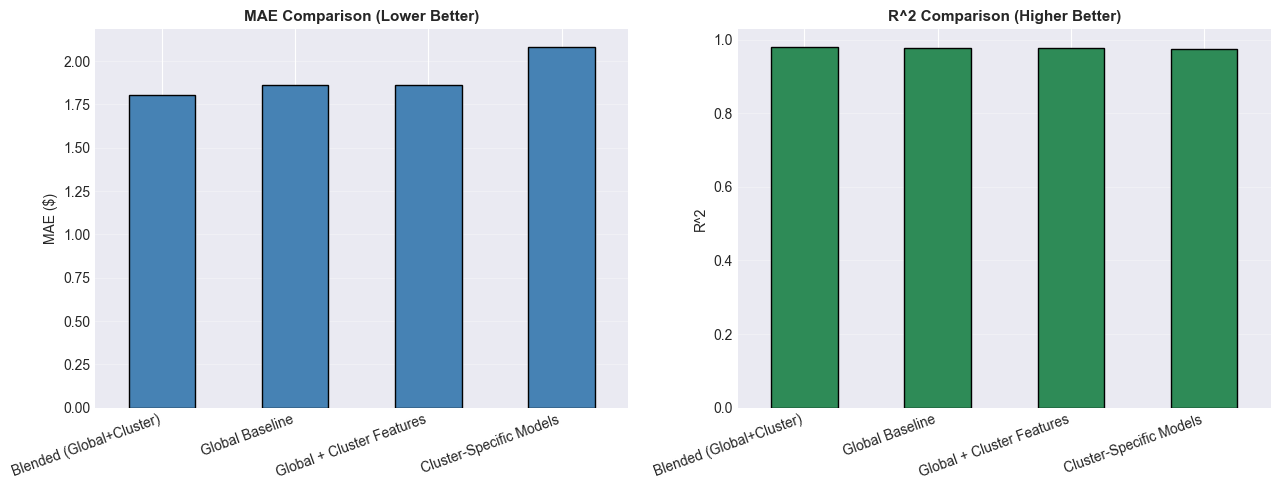

[OK] Saved: 09_cluster_aware_regression_comparison.png


In [117]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_df['MAE'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('MAE Comparison (Lower Better)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('MAE ($)')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')

metrics_df['R2'].plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('R^2 Comparison (Higher Better)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('R^2')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig(str(REG_GRAPH_DIR / '09_cluster_aware_regression_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print('[OK] Saved: 09_cluster_aware_regression_comparison.png')

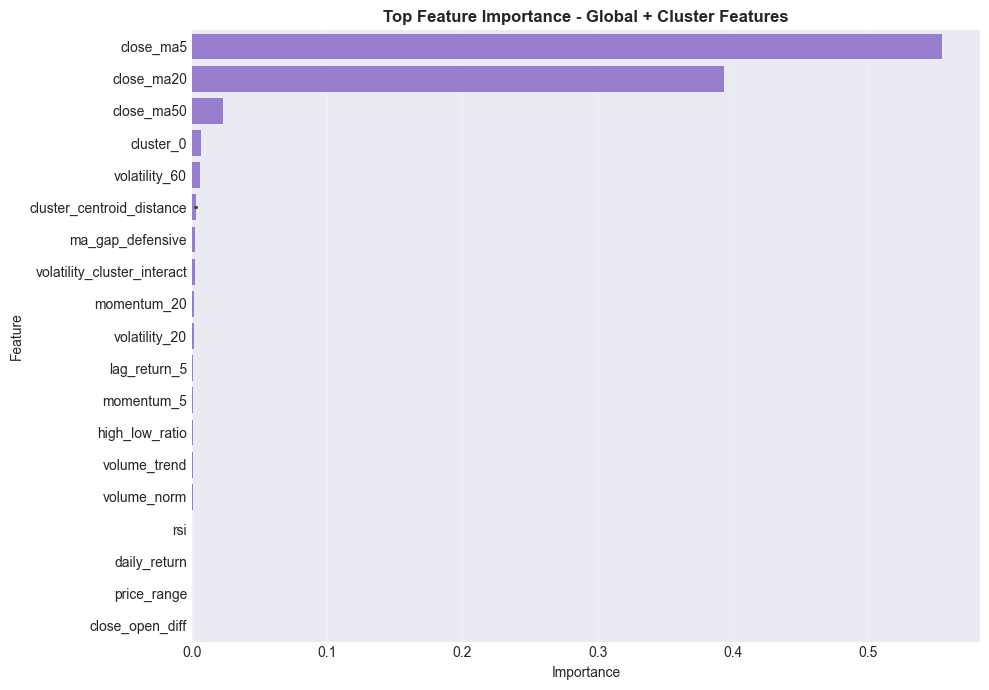

[OK] Saved: 10_cluster_aware_feature_importance.png
Top 20 features:


,feature,importance
8,close_ma5,0.555141
9,close_ma20,0.393613
10,close_ma50,0.022738
17,cluster_0,0.006555
14,volatility_60,0.005610
16,cluster_centroid_distance,0.003005
20,cluster_centroid_distance,0.002232
24,ma_gap_defensive,0.002199
25,volatility_cluster_interact,0.002140
12,momentum_20,0.001595


In [118]:
# Feature importance from enhanced global model
imp_df = pd.DataFrame({
    'feature': all_features,
    'importance': global_enh.feature_importances_
}).sort_values('importance', ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=imp_df.head(top_n), y='feature', x='importance', ax=ax, color='mediumpurple')
ax.set_title('Top Feature Importance - Global + Cluster Features', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(str(REG_GRAPH_DIR / '10_cluster_aware_feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()

print('[OK] Saved: 10_cluster_aware_feature_importance.png')
print('Top 20 features:')
display(imp_df.head(top_n))

In [119]:
# Cluster-level error analysis (using blended prediction)
test_eval = test_df[['Name', 'date', target_col]].copy()
test_eval['pred_blend'] = pred_blend

cluster_cols_test = [c for c in test_df.columns if c.startswith('cluster_') and c[len('cluster_'):].isdigit()]
cluster_cols_test = sorted(cluster_cols_test, key=lambda x: int(x.split('_')[1]))
cluster_ids_from_cols = [int(c.split('_')[1]) for c in cluster_cols_test]

# Map argmax position back to actual cluster id (e.g., [0, 1, 4] instead of [0, 1, 2])
cluster_pos = np.argmax(test_df[cluster_cols_test].values, axis=1)
test_eval['cluster_id'] = pd.Series(cluster_pos).map(lambda i: cluster_ids_from_cols[int(i)]).astype(int)

cluster_perf = []
for cid, g in test_eval.groupby('cluster_id'):
    y_t = g[target_col].values
    y_p = g['pred_blend'].values
    cluster_perf.append({
        'cluster_id': int(cid),
        'n_samples': len(g),
        'MAE': mean_absolute_error(y_t, y_p),
        'RMSE': np.sqrt(mean_squared_error(y_t, y_p)),
        'MAPE(%)': mean_absolute_percentage_error(y_t, y_p) * 100,
        'R2': r2_score(y_t, y_p)
    })

cluster_perf_df = pd.DataFrame(cluster_perf).sort_values('MAE')
display(cluster_perf_df)

output_csv = reg_root / 'data' / '02B_cluster_level_regression_performance.csv'
output_csv.parent.mkdir(parents=True, exist_ok=True)
cluster_perf_df.to_csv(output_csv, index=False)
print(f'[OK] Saved: {output_csv.name}')

,cluster_id,n_samples,MAE,RMSE,MAPE(%),R2
1,1,7537,1.227878,2.373365,1.029688,0.998494
0,0,12674,2.647558,10.628076,1.347760,0.988131
2,4,2426,3.632709,14.632326,1.645888,0.986227


[OK] Saved: 02B_cluster_level_regression_performance.csv


## Practical Findings
1. Cluster labels and centroid-distance add market-structure context into regression.
2. Cluster-specific interactions improve relevance of features per stock style.
3. Cluster-specific models reduce one-model-fits-all limitations.
4. Blended predictions can improve robustness across regimes.
5. Cluster-level MAE diagnostics reveal where the model still underperforms and where to refine features.